**Upload Dataset**

In [1]:
# import modules
!pip install -q selfies
from google.colab import drive
import numpy as np
import csv
import pandas as pd
import selfies as sf
from matplotlib.ticker import PercentFormatter

In [2]:
# mount the drive
drive.mount('/content/drive')
dir = "/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Model_1/"

# import the SELFIES alphabet
SELFIES_alphabet = np.load(dir + 'data/SELFIES_alphabet.npy',allow_pickle='TRUE').item()

# import the SELFIES dataset
with open(dir + 'data/338K_dataset.csv', newline='') as file:
    dataset = pd.read_csv(file)

Mounted at /content/drive


**Molecular Descriptor**

*One-Hot Encoding of Molecular Physical Structure*

In [3]:
# one-hot encoding
def OneHot(selfies):
    label, one_hot = sf.selfies_to_encoding(
            selfies=selfies,
            vocab_stoi=SELFIES_alphabet,
            pad_to_len=76,
            enc_type = "both")
    return one_hot

for i in range (0,len(dataset.index)):
  dataset['ion1'][i] = OneHot(dataset.iloc[i][1]) + OneHot(dataset.iloc[i][2])

del dataset['ion2']
dataset.rename(columns = {'ion1':'ions'}, inplace = True)

<ipython-input-3-f9e429160452>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['ion1'][i] = OneHot(dataset.iloc[i][1]) + OneHot(dataset.iloc[i][2])


*Proprocess Density*

In [4]:
dataset['density'] = dataset['density']/1000

**338.15K DNN Model Setup**

In [5]:
# upload transfer_learning.py
from google.colab import files
files.upload()

Saving transfer_learning.py to transfer_learning.py


{'transfer_learning.py': b'from __future__ import print_function, division\n\nimport torch\nimport torch.nn as nn \nimport torch.optim as optim\nfrom torch.optim import lr_scheduler\nfrom torch.autograd import Variable \n\nimport numpy as np \nimport matplotlib.pyplot as plt \nimport time \nimport os \n\nclass NeuralNet(nn.Module):\n\tdef __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):\n\t\tsuper(NeuralNet, self).__init__()\n\t\tself.fc1 = nn.Linear(input_size, hidden_size_1)\n\t\tself.fc2 = nn.Linear(hidden_size_1, hidden_size_2)\n\t\tself.fc3 = nn.Linear(hidden_size_2, output_size)\n\t\tself.relu = nn.ReLU()\n\n\tdef forward(self, x):\n\t\tout = self.fc1(x)\n\t\tout = self.relu(out)\n\t\tout = self.fc2(out)\n\t\tout = self.relu(out)\n\t\tout = self.fc3(out)\n\t\treturn out \n'}

In [6]:
# transfer_learning.py
from transfer_learning import NeuralNet

# principal component analysis
from sklearn.decomposition import PCA

# DNN training
import torch
import torch.nn as nn
import torch.optim as optim
import os, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# permutation feature importance
!pip install -q eli5
from sklearn.neural_network import MLPRegressor
import eli5
from eli5.sklearn import PermutationImportance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 16.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [7]:
# input X and output y
X = []
y = []
for i in range(0,len(dataset.index)):
    X.append(dataset['ions'][i])
    y.append(dataset['density'][i])
for i in range(0,len(X)):
  X[i] = np.array(X[i]).reshape(7904,).astype(np.float32)
  y[i] = y[i].astype(np.float32)
X = np.array(X)
y = np.array(y)

**Model A: 50 Principle Components**

*DNN Model*

100%|██████████| 20000/20000 [00:32<00:00, 621.97it/s]


The MAPE on test set is 4.803213104605675%


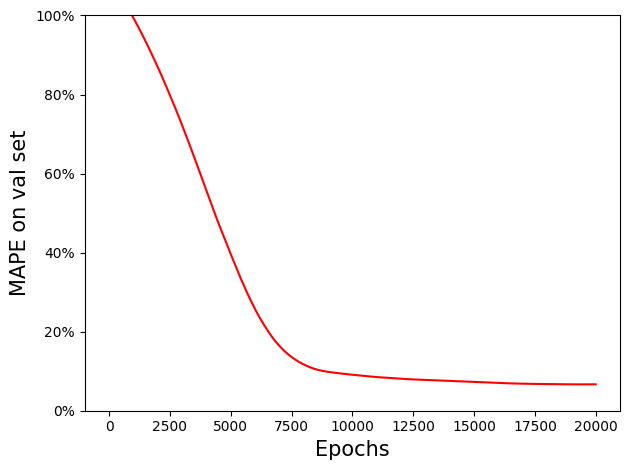

In [8]:
# PCA
PC = []
for i in range (1, 51):
  PC.append('PC'+str(i))
pca = PCA(n_components = 50)
pca.fit(X)
data_pca = pca.transform(X)
df_PCA = pd.DataFrame(data_pca,columns=PC)
X_PCA = df_PCA.to_numpy()

# DNN training
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.00001

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 20000
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val).to(device)
        labels_val = torch.from_numpy(y_val).to(device)

        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.ylim(0,1)
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)

X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

output_test = model(X_test_tensor).view(-1,).cpu().data.numpy()

mape_test = mean_absolute_percentage_error(y_test_tensor.cpu().data.numpy(), output_test) * 100

print('The MAPE on test set is {}%'.format(mape_test))

plt.tight_layout()
plt.savefig(dir + 'figures/338.15K/A_training_curve.png', dpi=600)

*Learning Curve*

In [ ]:
# learning curve
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.00001

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

x = 3
error_train = np.zeros(int(len(X_train)/x))
error_val = np.zeros(int(len(X_train)/x))

for i,N in enumerate(range(x, len(X_train)+1, x)):
  X_train_LC = X_train[:N]
  y_train_LC = y_train[:N]
  X_val_LC = X_val
  y_val_LC = y_val
  
  model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  val_scores_epochs = list()
  train_scores_epochs = list()
  num_epochs = 20000

  for epoch in tqdm(range(num_epochs)):
      inputs = torch.from_numpy(X_train_LC).to(device)
      labels = torch.from_numpy(y_train_LC).to(device)

      outputs = model(inputs).view(-1,)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_scores_epochs.append(loss)

      inputs_val = torch.from_numpy(X_val_LC).to(device)
      labels_val = torch.from_numpy(y_val_LC).to(device)

      outputs_val = model(inputs_val).view(-1,)
      score = mean_squared_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
      val_scores_epochs.append(score)

  error_train[i] = train_scores_epochs[-1]
  error_val[i] = val_scores_epochs[-1] 

df_error_train = pd.DataFrame(error_train)
df_error_val = pd.DataFrame(error_val)

df_error_train.to_csv(dir + 'figures/data/learning_curve/A_338.15K_train.csv') 
df_error_val.to_csv(dir + 'figures/data/learning_curve/A_338.15K_val.csv') 

100%|██████████| 20000/20000 [00:41<00:00, 484.26it/s]


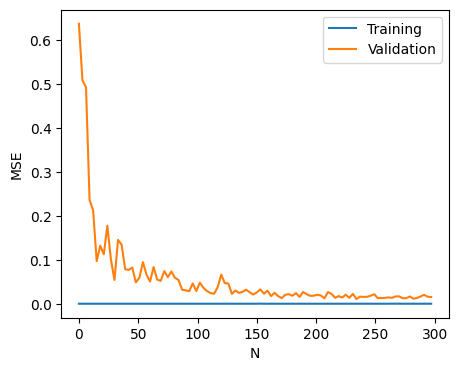

In [ ]:
x_axis = list()
for i,N in enumerate(range(x, len(X_train)+1, x)):
  x_axis.append(i*x)

with open(dir + 'figures/data/learning_curve/A_338.15K_train.csv', newline='') as file1:
    csv_error_train = pd.read_csv(file1)
with open(dir + 'figures/data/learning_curve/A_338.15K_val.csv', newline='') as file2:
    csv_error_val = pd.read_csv(file2)

csv_error_train.columns =['index', 'loss']
csv_error_val.columns =['index', 'loss']

lst_error_train = csv_error_train['loss'].tolist()
lst_error_val = csv_error_val['loss'].tolist()
plt.figure(figsize=(5,4))
plt.plot(x_axis, lst_error_train, label='Training')
plt.plot(x_axis, lst_error_val, label='Validation')
plt.legend()
plt.ylabel('MSE')
plt.xlabel('N')
plt.savefig(dir + 'figures/338.15K/A_learning_curve.png', format='png', dpi=600)

*Feature Importance Analysis*

In [ ]:
regr = MLPRegressor(hidden_layer_sizes=(30, 15), solver='adam', activation = 'relu', random_state=1, max_iter=20000, learning_rate='constant',learning_rate_init=0.00001).fit(X_train, y_train)
perm = PermutationImportance(regr.fit(X_train,y_train), random_state=1).fit(X_test,y_test)
eli5.formatters.as_dataframe.explain_weights_df(perm, feature_names = df_PCA.columns.tolist(), top=50).to_csv(dir + 'figures/data/feature_importance/A_338.15K.csv')

**TL Model A: Density from 298-299K to 338.15K**

*(1) Monitor Initial Validation Loss Fluctuation*

In [ ]:
# plot validation loss for DL and TL batches

def transfer_learning(transfer=False, nsamples=None, nbatches=None, num_epochs=None):
    seeds = np.arange(nbatches)
    Ns = list()
    scores_test = list()
    scores_train = list()

    # dataset pre-processing
    for seed in tqdm(seeds):
        data_small = dataset.sample(n=nsamples, random_state=seed).reset_index(drop=True)
        X_small = []
        y_small = []
        for i in range(0, len(data_small.index)):
            X_small.append(data_small['ions'][i])
            y_small.append(data_small['density'][i])
        for i in range(0, len(X_small)):
            X_small[i] = np.array(X_small[i]).reshape(7904,).astype(np.float32)
            y_small[i] = y_small[i].astype(np.float32)
        X_small = np.array(X_small)
        y_small = np.array(y_small)

        PC_small = []
        for i in range(1, 51):
            PC_small.append('PC'+str(i))
        pca = PCA(n_components=50)
        pca.fit(X_small)
        data_small_pca = pca.transform(X_small)
        df_small_PCA = pd.DataFrame(data_small_pca, columns=PC_small)
        X_small_PCA = df_small_PCA.to_numpy()

        # model architecture
        input_size = 50
        hidden_size_1 = 30
        hidden_size_2 = 15
        output_size = 1
        learning_rate = 0.0001 

        model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

        # if transfer = True, transfer pre-trained weights
        if transfer:
            model.load_state_dict(torch.load(dir + 'model/298_299K/A_298_299K_model.ckpt'))
            model.fc1.weight.requires_grad = False
            model.fc1.bias.requires_grad = False
            model.fc2.weight.requires_grad = False
            model.fc2.bias.requires_grad = False

        # dataset splitting
        X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small_PCA, y_small, test_size=0.1, random_state=1)
        X_small_train, X_small_val, y_small_train, y_small_val = train_test_split(X_small_train, y_small_train, test_size=0.2, random_state=1)

        N = 0
        train_losses = []
        val_losses = []

        for epoch in range(num_epochs):

            # training
            inputs_tl = torch.from_numpy(X_small_train).to(device)
            labels_tl = torch.from_numpy(y_small_train).to(device)
            outputs_tl = model(inputs_tl).view(-1,)
            loss = criterion(outputs_tl, labels_tl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            N += 1

            # validation
            inputs_val = torch.from_numpy(X_small_val).to(device)
            labels_val = torch.from_numpy(y_small_val).to(device)
            outputs_val = model(inputs_val).view(-1,)
            val_loss = criterion(outputs_val, labels_val)
            val_losses.append(val_loss.item())

        # plotting
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epochs', size=15)
        plt.ylabel('MSE Loss', size=15)
        
        Ns.append(N)

100%|██████████| 100/100 [03:05<00:00,  1.86s/it]


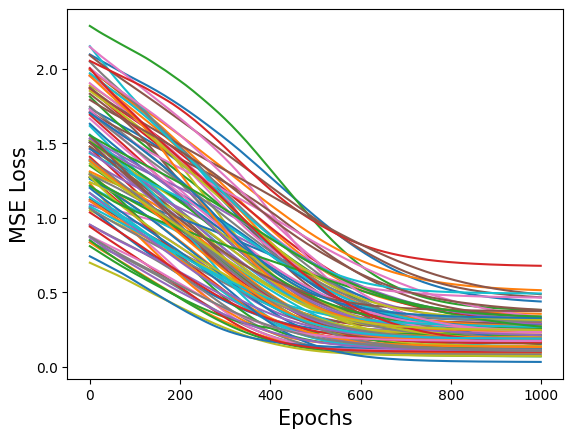

In [ ]:
transfer_learning(transfer=False, nsamples=50, nbatches=100, num_epochs=1000)

100%|██████████| 100/100 [42:24<00:00, 25.45s/it]


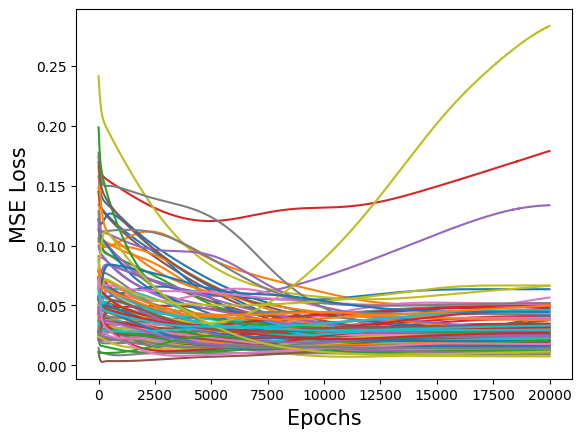

In [ ]:
transfer_learning(transfer=True, nsamples=50, nbatches=100, num_epochs=20000)

*(2) Direct Learning vs Transfer Learning*

In [ ]:
def transfer_learning(transfer=False, nsamples=None, nbatches=None, patience=None, ylim=None):
    seeds = np.arange(nbatches)
    Ns = list()
    scores_test = list()
    scores_train = list()

    # dataset pre-processing
    for seed in tqdm(seeds):
        data_small = dataset.sample(n=nsamples, random_state=seed).reset_index(drop=True)
        X_small = []
        y_small = []
        for i in range(0, len(data_small.index)):
            X_small.append(data_small['ions'][i])
            y_small.append(data_small['density'][i])
        for i in range(0, len(X_small)):
            X_small[i] = np.array(X_small[i]).reshape(7904,).astype(np.float32)
            y_small[i] = y_small[i].astype(np.float32)
        X_small = np.array(X_small)
        y_small = np.array(y_small)

        PC_small = []
        for i in range(1, 51):
            PC_small.append('PC'+str(i))
        pca = PCA(n_components=50)
        pca.fit(X_small)
        data_small_pca = pca.transform(X_small)
        df_small_PCA = pd.DataFrame(data_small_pca, columns=PC_small)
        X_small_PCA = df_small_PCA.to_numpy()
       
        # model architecture
        input_size = 50
        hidden_size_1 = 30
        hidden_size_2 = 15
        output_size = 1
        learning_rate = 0.0001
        num_epochs = 50000

        model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
        
        # if transfer = True, transfer pre-trained weights
        if transfer:
            model.load_state_dict(torch.load(dir + 'model/298_299K/A_298_299K_model.ckpt'))
            model.fc1.weight.requires_grad = False
            model.fc1.bias.requires_grad = False
            model.fc2.weight.requires_grad = False
            model.fc2.bias.requires_grad = False

        # dataset splitting
        X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small_PCA, y_small, test_size=0.1, random_state=1)
        X_small_train, X_small_val, y_small_train, y_small_val = train_test_split(X_small_train, y_small_train, test_size=0.2, random_state=1)

        N = 0
        train_losses = []
        val_losses = []
        val_loss_min = float('inf')
        early_stopping_counter = 0

        for epoch in range(num_epochs):
            # training
            inputs_tl = torch.from_numpy(X_small_train).to(device)
            labels_tl = torch.from_numpy(y_small_train).to(device)
            outputs_tl = model(inputs_tl).view(-1,)
            loss = criterion(outputs_tl, labels_tl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss = 0
            running_loss += loss.item()
            train_losses.append(running_loss)

            N += 1

            # validation
            inputs_val = torch.from_numpy(X_small_val).to(device)
            labels_val = torch.from_numpy(y_small_val).to(device)
            outputs_val = model(inputs_val).view(-1,)
            val_loss = criterion(outputs_val, labels_val)
            val_losses.append(val_loss.item())

            # stopping criteria
            if val_loss < val_loss_min:
                val_loss_min = val_loss
                early_stopping_counter = 0
            else:
                early_stopping_counter += 1
                if early_stopping_counter >= patience:
                    break
        
        # plotting   
        plt.ylim(0,ylim)
        plt.plot(train_losses, label='Training Loss')
        plt.xlabel('Epochs', size=15)
        plt.ylabel('MSE Loss', size=15)
        
        Ns.append(N)

        X_small_train_tensor = torch.from_numpy(X_small_train).to(device)
        y_small_train_tensor = torch.from_numpy(y_small_train).to(device)
        X_small_test_tensor = torch.from_numpy(X_small_test).to(device)
        y_small_test_tensor = torch.from_numpy(y_small_test).to(device)

        # scores
        score_train = mean_absolute_percentage_error(y_small_train_tensor.cpu().numpy(), model(X_small_train_tensor).view(-1,).cpu().data.numpy())
        scores_train.append(score_train)
        score_test = mean_absolute_percentage_error(y_small_test_tensor.cpu().numpy(), model(X_small_test_tensor).view(-1,).cpu().data.numpy())
        scores_test.append(score_test)

    return scores_train, scores_test

In [ ]:
def calculate_mean(csv_path):
    df = pd.read_csv(csv_path, header=None)
    mean_value = df.iloc[:, 1].mean()
    return mean_value

*Direct Learning*
*   patience = 300
1.   Validation loss steadily going down, so no warm-up epochs necessary
2.   All training loss converges before 3000, so the patience is set at its 10% place, which is 300

100%|██████████| 100/100 [08:01<00:00,  4.82s/it]


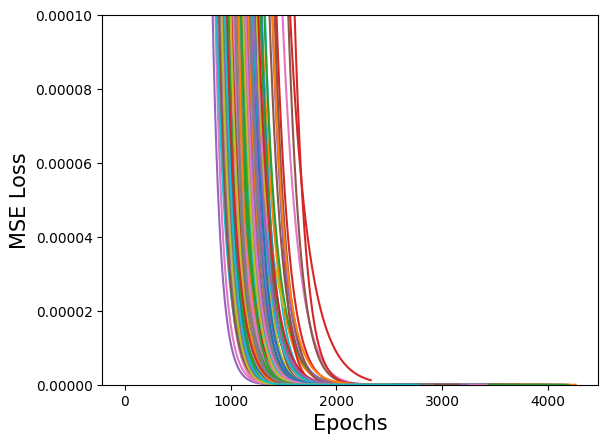

In [ ]:
scores_train_wo_transfer, scores_test_wo_transfer = transfer_learning(transfer=False, nsamples=50, nbatches=100, patience=300, ylim=0.0001)
pd.DataFrame(scores_test_wo_transfer).to_csv(dir + 'figures/data/DNN_score/A_338.15K_DL_p300.csv')

*Transfer Learning*
*   patience = 2000
1.   Most validation fluctuation that leads to lower validation loss happens before 2000 epochs
2.   All training loss converages before 20000, so the patience is set at its 10% place, which is 2000
3.   We tried different patience levels below 5000, and the best testing accuracy is ~13% MAPE

100%|██████████| 100/100 [24:02<00:00, 14.43s/it]


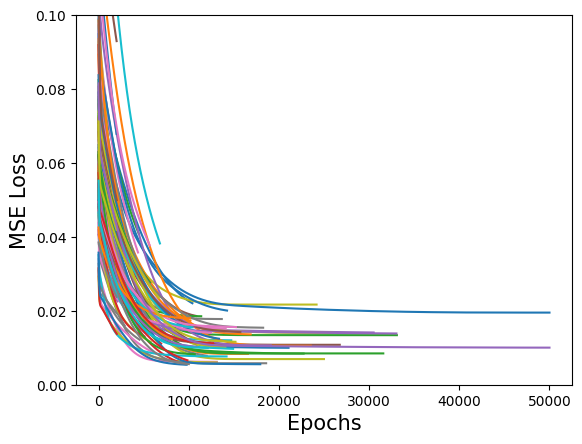

In [ ]:
scores_train_w_transfer, scores_test_w_transfer = transfer_learning(transfer=True, nsamples=50, nbatches=100, patience=2000, ylim=0.1)
pd.DataFrame(scores_test_w_transfer).to_csv(dir + 'figures/data/DNN_score/A_338.15K_TL_p2000.csv')

In [ ]:
avg_MAPE_DL = calculate_mean(dir + 'figures/data/DNN_score/A_338.15K_DL_p300.csv')
avg_MAPE_TL = calculate_mean(dir + 'figures/data/DNN_score/A_338.15K_TL_p2000.csv')
print("avg DL MAPE: ", avg_MAPE_DL*100, '%' )
print("avg TL MAPE: ", avg_MAPE_TL*100, '%')

avg DL MAPE:  32.860251168316836 %
avg TL MAPE:  13.10018146336634 %


**Model B: 285 SELFIES-Collapsed Features**

*DNN Model*

In [ ]:
# filter out 285 features with nonzero-importance
nonzero_feature_index = [4835, 861, 29, 806, 1039, 4480, 767, 4810, 1222, 681, 18, 4460, 4654, 4862, 3990, 4009, 1170, 384, 4633, 234, 1112, 4620, 4285, 4220, 229, 508, 724, 78, 5063, 516, 378, 5070, 586, 57, 100, 5798, 170, 601, 92, 4117, 4141, 4740, 4562, 27, 26, 5018, 5642, 4428, 794, 450, 4170, 4109, 4516, 592, 4544, 4477, 1091, 4939, 488, 4891, 4731, 4453, 4302, 4238, 4290, 4270, 653, 913, 4328, 4828, 1381, 846, 546, 4336, 1485, 984, 125, 1507, 5590, 3992, 4568, 159, 403, 5538, 1559, 4532, 4324, 213, 5694, 4329, 889, 317, 727, 222, 4024, 4284, 34, 109, 4193, 4250, 200, 1589, 4856, 1586, 1268, 4966, 757, 4134, 280, 4737, 598, 1106, 148, 4914, 5850, 1225, 1262, 4841, 4724, 1403, 454, 1351, 4839, 883, 4783, 935, 632, 246, 1663, 4168, 338, 33, 5954, 4212, 1149, 4596, 456, 4201, 421, 1693, 4197, 473, 1715, 658, 4887, 702, 5902, 525, 612, 4679, 4263, 390, 4425, 993, 1118, 1002, 356, 5064, 1066, 162, 4752, 4004, 4474, 48, 4505, 809, 715, 644, 1143, 5875, 5746, 1299, 4948, 663, 72, 124, 5272, 408, 1641, 103, 559, 1287, 4636, 4044, 4668, 326, 38, 4772, 1326, 4409, 5486, 4550, 623, 196, 5563, 1534, 4493, 1433, 265, 256, 1097, 351, 754, 4082, 5459, 650, 1455, 149, 308, 831, 369, 4057, 161, 4492, 5304, 73, 207, 680, 4100, 4030, 4627, 4394, 4715, 305, 424, 4991, 573, 4368, 962, 4376, 248, 779, 130, 4297, 5174, 5979, 4464, 430, 440, 442, 1247, 4304, 1183, 1195, 987, 4896, 5122, 216, 482, 152, 5226, 4377, 5382, 5355, 1430, 494, 1210, 733, 519, 638, 47, 146, 4804, 611, 5434, 5006, 5043, 315, 910, 4513, 1274, 871, 4356, 4217, 675, 4160, 858, 5012, 4473, 402, 242, 4591, 4310, 332, 4581]
X_filtered =[[]for i in range(len(dataset.index))]
for i in range (0,len(dataset.index)):
  for j in nonzero_feature_index:
    X_filtered[i].append(X[i][j])
X_filtered = np.array(X_filtered)
column = list()
for i in nonzero_feature_index:
  column.append('#' + str(i))
df_X_filtered = pd.DataFrame(X_filtered,columns= column)

100%|██████████| 800/800 [00:01<00:00, 597.87it/s]


The MAPE on test set is 5.421342700719833%


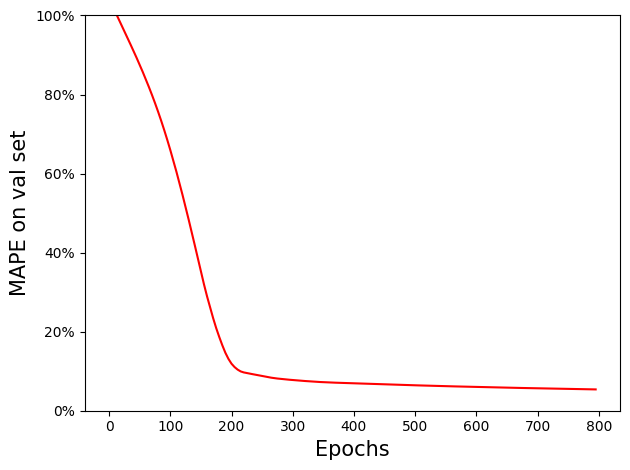

In [ ]:
# DNN training
input_size = 285
hidden_size_1 = 190
hidden_size_2 = 95
output_size = 1
learning_rate = 0.00003

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 800
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val).to(device)
        labels_val = torch.from_numpy(y_val).to(device)

        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.ylim(0,1)
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)

X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

output_test = model(X_test_tensor).view(-1,).cpu().data.numpy()

mape_test = mean_absolute_percentage_error(y_test_tensor.cpu().data.numpy(), output_test) * 100

print('The MAPE on test set is {}%'.format(mape_test))

plt.tight_layout()
plt.savefig(dir + 'figures/338.15K/B_training_curve.png', dpi=600)

*Learning Curve*

In [ ]:
# learning curve
input_size = 285
hidden_size_1 = 190
hidden_size_2 = 95
output_size = 1
learning_rate = 0.00003

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

x = 3
error_train = np.zeros(int(len(X_train)/x))
error_val = np.zeros(int(len(X_train)/x))

for i,N in enumerate(range(x, len(X_train)+1, x)):
  X_train_LC = X_train[:N]
  y_train_LC = y_train[:N]
  X_val_LC = X_val
  y_val_LC = y_val
  
  model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  val_scores_epochs = list()
  train_scores_epochs = list()
  num_epochs = 800

  for epoch in tqdm(range(num_epochs)):
      inputs = torch.from_numpy(X_train_LC).to(device)
      labels = torch.from_numpy(y_train_LC).to(device)

      outputs = model(inputs).view(-1,)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_scores_epochs.append(loss)

      inputs_val = torch.from_numpy(X_val_LC).to(device)
      labels_val = torch.from_numpy(y_val_LC).to(device)

      outputs_val = model(inputs_val).view(-1,)
      score = mean_squared_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
      val_scores_epochs.append(score)

  error_train[i] = train_scores_epochs[-1]
  error_val[i] = val_scores_epochs[-1] 

df_error_train = pd.DataFrame(error_train)
df_error_val = pd.DataFrame(error_val)

df_error_train.to_csv(dir + 'figures/data/learning_curve/B_338.15K_train.csv') 
df_error_val.to_csv(dir + 'figures/data/learning_curve/B_338.15K_val.csv')

100%|██████████| 800/800 [00:01<00:00, 429.93it/s]


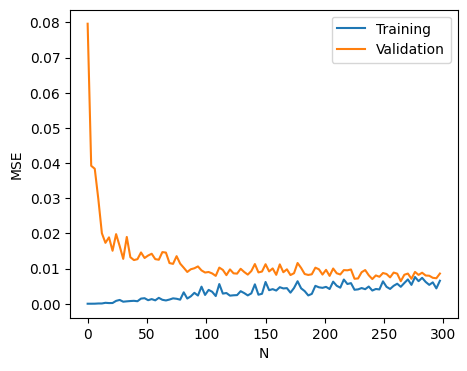

In [ ]:
x_axis = list()
for i,N in enumerate(range(x, len(X_train)+1, x)):
  x_axis.append(i*x)

with open(dir + 'figures/data/learning_curve/B_338.15K_train.csv', newline='') as file1:
    csv_error_train = pd.read_csv(file1)
with open(dir + 'figures/data/learning_curve/B_338.15K_val.csv', newline='') as file2:
    csv_error_val = pd.read_csv(file2)

csv_error_train.columns =['index', 'loss']
csv_error_val.columns =['index', 'loss']

lst_error_train = csv_error_train['loss'].tolist()
lst_error_val = csv_error_val['loss'].tolist()
plt.figure(figsize=(5,4))
plt.plot(x_axis, lst_error_train, label='Training')
plt.plot(x_axis, lst_error_val, label='Validation')
plt.legend()
plt.ylabel('MSE')
plt.xlabel('N')
plt.savefig(dir + 'figures/338.15K/B_learning_curve.png', format='png', dpi=600)

*Feature Importance Analysis*

In [ ]:
regr = MLPRegressor(hidden_layer_sizes=(190, 95), solver='adam', activation = 'relu', random_state=1, max_iter=800, learning_rate='constant',learning_rate_init=0.00003).fit(X_train, y_train)
perm = PermutationImportance(regr.fit(X_train,y_train), random_state=1).fit(X_test,y_test)
eli5.formatters.as_dataframe.explain_weights_df(perm, feature_names = df_X_filtered.columns.tolist(), top=285).to_csv(dir + 'figures/data/feature_importance/B_338.15K.csv')

**TL Model B: Density from 298-299K to 283.15K**

*(1) Monitor Initial Validation Loss Fluctuation*

In [ ]:
# plot validation loss for DL and TL batches

def transfer_learning(transfer=False, nsamples=None, nbatches=None, num_epochs=None):
    seeds = np.arange(nbatches)
    Ns = list()
    scores_test = list()
    scores_train = list()

    # dataset pre-processing
    for seed in tqdm(seeds):
        data_small = dataset.sample(n=nsamples, random_state=seed).reset_index(drop=True)
        X_small = []
        y_small = []
        for i in range(0, len(data_small.index)):
            X_small.append(data_small['ions'][i])
            y_small.append(data_small['density'][i])
        for i in range(0, len(X_small)):
            X_small[i] = np.array(X_small[i]).reshape(7904,).astype(np.float32)
            y_small[i] = y_small[i].astype(np.float32)
        X_small = np.array(X_small)
        y_small = np.array(y_small)

        X_small_filtered = [[] for i in range(nsamples)]
        for i in range(nsamples):
            for j in nonzero_feature_index:
                X_small_filtered[i].append(X_small[i][j])
        X_small_filtered = np.array(X_small_filtered)

        # model architecture
        input_size = 285
        hidden_size_1 = 190
        hidden_size_2 = 95
        output_size = 1
        learning_rate = 0.0001 

        model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

        # if transfer = True, transfer pre-trained weights
        if transfer:
            model.load_state_dict(torch.load(dir + 'model/298_299K/B_298_299K_model.ckpt'))
            model.fc1.weight.requires_grad = False
            model.fc1.bias.requires_grad = False
            model.fc2.weight.requires_grad = False
            model.fc2.bias.requires_grad = False

        # dataset splitting
        X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small_filtered, y_small, test_size=0.1, random_state=1)
        X_small_train, X_small_val, y_small_train, y_small_val = train_test_split(X_small_train, y_small_train, test_size=0.2, random_state=1)

        N = 0
        train_losses = []
        val_losses = []

        for epoch in range(num_epochs):

            # training
            inputs_tl = torch.from_numpy(X_small_train).to(device)
            labels_tl = torch.from_numpy(y_small_train).to(device)
            outputs_tl = model(inputs_tl).view(-1,)
            loss = criterion(outputs_tl, labels_tl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            N += 1

            # validation
            inputs_val = torch.from_numpy(X_small_val).to(device)
            labels_val = torch.from_numpy(y_small_val).to(device)
            outputs_val = model(inputs_val).view(-1,)
            val_loss = criterion(outputs_val, labels_val)
            val_losses.append(val_loss.item())

        # plotting
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epochs', size=15)
        plt.ylabel('MSE Loss', size=15)
        
        Ns.append(N)

100%|██████████| 100/100 [00:20<00:00,  4.87it/s]


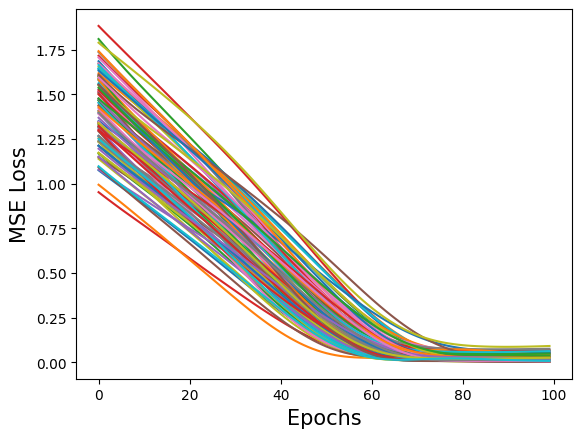

In [ ]:
transfer_learning(transfer=False, nsamples=50, nbatches=100, num_epochs=100)

100%|██████████| 100/100 [02:12<00:00,  1.33s/it]


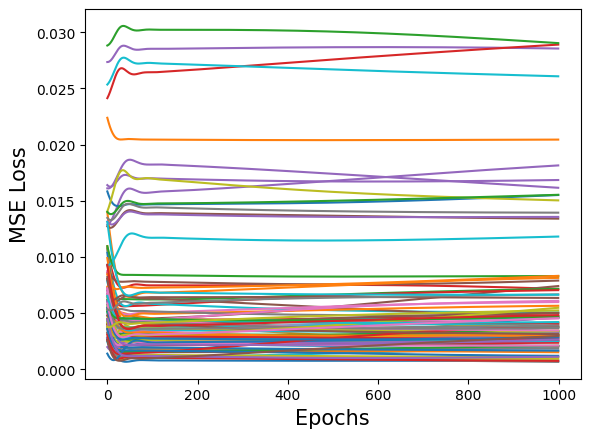

In [ ]:
transfer_learning(transfer=True, nsamples=50, nbatches=100, num_epochs=1000)

*(2) Direct Learning vs Transfer Learning*

In [ ]:
def transfer_learning(transfer=False, nsamples=None, nbatches=None, patience=None, ylim=None):
    seeds = np.arange(nbatches)
    Ns = list()
    scores_test = list()
    scores_train = list()

    for seed in tqdm(seeds):
        data_small = dataset.sample(n=nsamples, random_state=seed).reset_index(drop=True)
        X_small = []
        y_small = []
        for i in range(0, len(data_small.index)):
            X_small.append(data_small['ions'][i])
            y_small.append(data_small['density'][i])
        for i in range(0, len(X_small)):
            X_small[i] = np.array(X_small[i]).reshape(7904,).astype(np.float32)
            y_small[i] = y_small[i].astype(np.float32)
        X_small = np.array(X_small)
        y_small = np.array(y_small)

        X_small_filtered = [[] for i in range(nsamples)]
        for i in range(nsamples):
            for j in nonzero_feature_index:
                X_small_filtered[i].append(X_small[i][j])
        X_small_filtered = np.array(X_small_filtered)

        input_size = 285
        hidden_size_1 = 190
        hidden_size_2 = 95
        output_size = 1
        learning_rate = 0.0001
        num_epochs = 50000

        model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

        if transfer:
            model.load_state_dict(torch.load(dir + 'model/298_299K/B_298_299K_model.ckpt'))
            model.fc1.weight.requires_grad = False
            model.fc1.bias.requires_grad = False
            model.fc2.weight.requires_grad = False
            model.fc2.bias.requires_grad = False

        X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small_filtered, y_small, test_size=0.1, random_state=1)
        X_small_train, X_small_val, y_small_train, y_small_val = train_test_split(X_small_train, y_small_train, test_size=0.2, random_state=1)

        N = 0
        train_losses = []
        val_losses = []
        val_loss_min = float('inf')
        early_stopping_counter = 0

        for epoch in range(num_epochs):
            inputs_tl = torch.from_numpy(X_small_train).to(device)
            labels_tl = torch.from_numpy(y_small_train).to(device)
            outputs_tl = model(inputs_tl).view(-1,)
            loss = criterion(outputs_tl, labels_tl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss = 0
            running_loss += loss.item()
            train_losses.append(running_loss)

            N += 1

            inputs_val = torch.from_numpy(X_small_val).to(device)
            labels_val = torch.from_numpy(y_small_val).to(device)
            outputs_val = model(inputs_val).view(-1,)
            val_loss = criterion(outputs_val, labels_val)
            val_losses.append(val_loss.item())

            if val_loss < val_loss_min:
                val_loss_min = val_loss
                early_stopping_counter = 0
            else:
                early_stopping_counter += 1
                if early_stopping_counter >= patience:
                    break
        
        plt.ylim(0,ylim)
        plt.plot(train_losses, label='Training Loss')
        plt.xlabel('Epochs', size=15)
        plt.ylabel('MSE Loss', size=15)
        
        Ns.append(N)

        X_small_train_tensor = torch.from_numpy(X_small_train).to(device)
        y_small_train_tensor = torch.from_numpy(y_small_train).to(device)
        X_small_test_tensor = torch.from_numpy(X_small_test).to(device)
        y_small_test_tensor = torch.from_numpy(y_small_test).to(device)

        score_train = mean_absolute_percentage_error(y_small_train_tensor.cpu().numpy(), model(X_small_train_tensor).view(-1,).cpu().data.numpy())
        scores_train.append(score_train)
        score_test = mean_absolute_percentage_error(y_small_test_tensor.cpu().numpy(), model(X_small_test_tensor).view(-1,).cpu().data.numpy())
        scores_test.append(score_test)

    return scores_train, scores_test

In [ ]:
def calculate_mean(csv_path):
    df = pd.read_csv(csv_path, header=None)
    mean_value = df.iloc[:, 1].mean()
    return mean_value

*Direct Learning*
*   patience = 300
1.   Validation loss steadily going down, so no warm-up epochs necessary
2.   All training loss converges before 3000, so the patience is set at its 10% place, which is 300

100%|██████████| 100/100 [02:28<00:00,  1.48s/it]


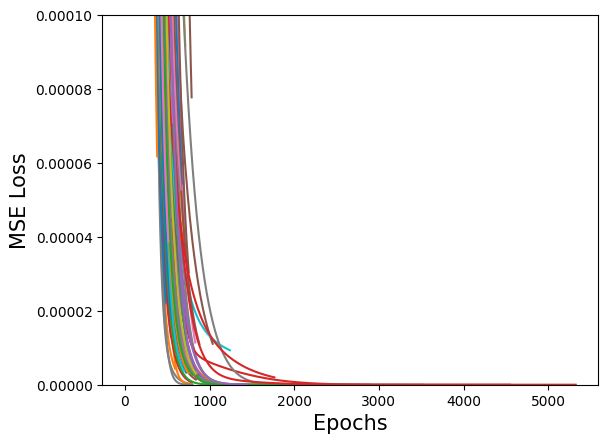

In [ ]:
scores_train_wo_transfer, scores_test_wo_transfer = transfer_learning(transfer=False, nsamples=50, nbatches=100, patience=300, ylim=0.0001)
pd.DataFrame(scores_test_wo_transfer).to_csv(dir + 'figures/data/DNN_score/B_338.15K_DL_p300.csv')

*Transfer Learning*
*   patience = 100
1.   Validation loss not changing much, even at 0.00001 learning rate, so no warm-up epochs necessary as patience level will be able to tolerate the initial fluctuations if any
2.   Since validation loss is not changing much, the patience level is set to be low, only to accommodate the initial fluctuation

100%|██████████| 100/100 [00:38<00:00,  2.59it/s]


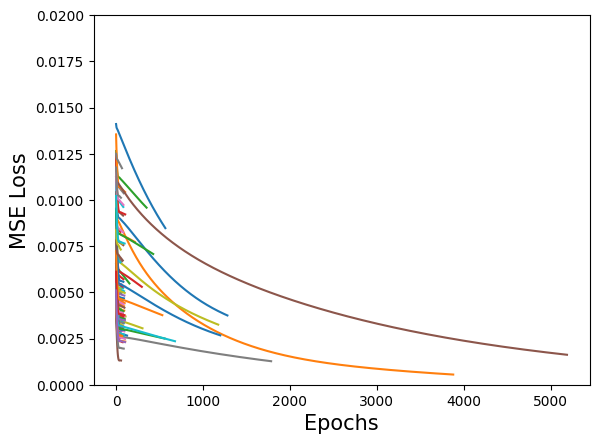

In [ ]:
scores_train_w_transfer, scores_test_w_transfer = transfer_learning(transfer=True, nsamples=50, nbatches=100, patience=50, ylim=0.02)
pd.DataFrame(scores_test_w_transfer).to_csv(dir + 'figures/data/DNN_score/B_338.15K_TL_p50.csv')

*(3) Result Summary*

In [ ]:
avg_MAPE_DL = calculate_mean(dir + 'figures/data/DNN_score/B_338.15K_DL_p300.csv')
avg_MAPE_TL = calculate_mean(dir + 'figures/data/DNN_score/B_338.15K_TL_p50.csv')
print("avg DL MAPE: ", avg_MAPE_DL*100, '%' )
print("avg TL MAPE: ", avg_MAPE_TL*100, '%')

avg DL MAPE:  8.103565363366336 %
avg TL MAPE:  4.770802574257425 %
